# Intel RealSense
https://www.intel.co.jp/content/www/jp/ja/architecture-and-technology/realsense-overview.html

In [25]:
import pyrealsense2 as rs
import numpy as np
import cv2
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import time

## テスト

RealSenseカメラから画像を取得中...
Frame 3: 現在のFPS = 172.5
Frame 4: 現在のFPS = 1120.6
Frame 5: 現在のFPS = 44.4
Frame 6: 現在のFPS = 53.6
Frame 7: 現在のFPS = 128.1
画像取得完了!
RealSenseパイプライン停止


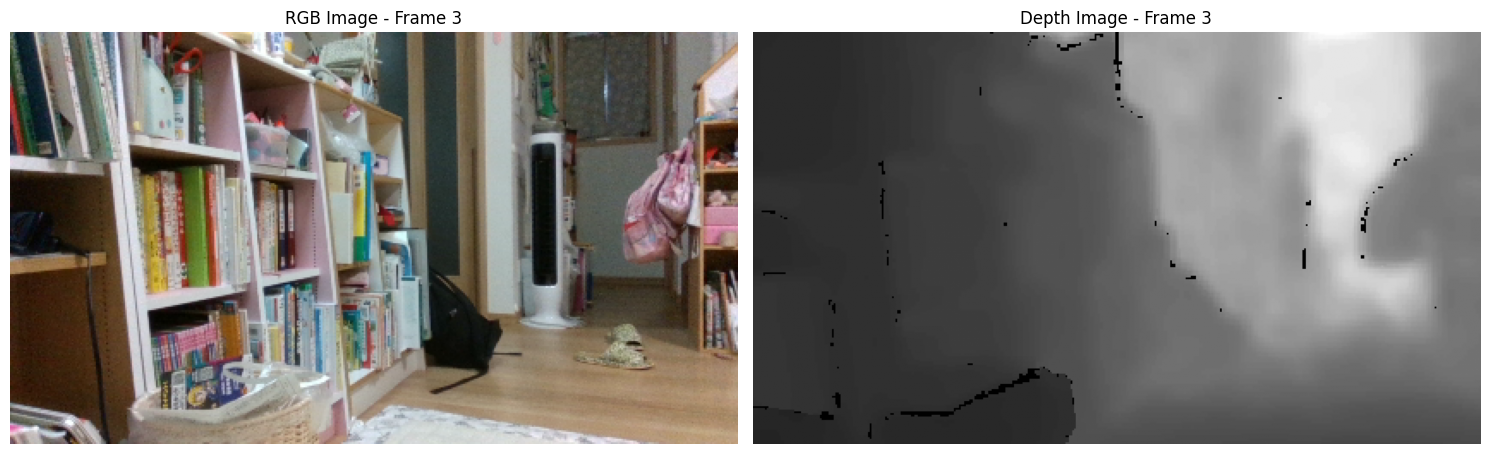

Frame 3: 中央のピクセル(212, 120)の距離: 1.515m


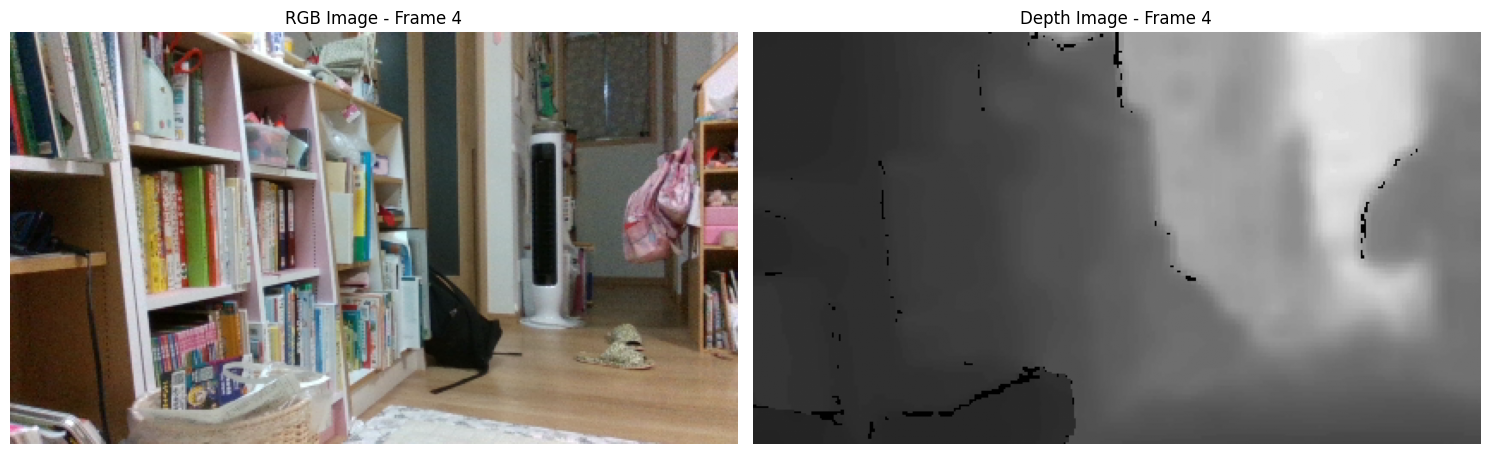

Frame 4: 中央のピクセル(212, 120)の距離: 1.515m


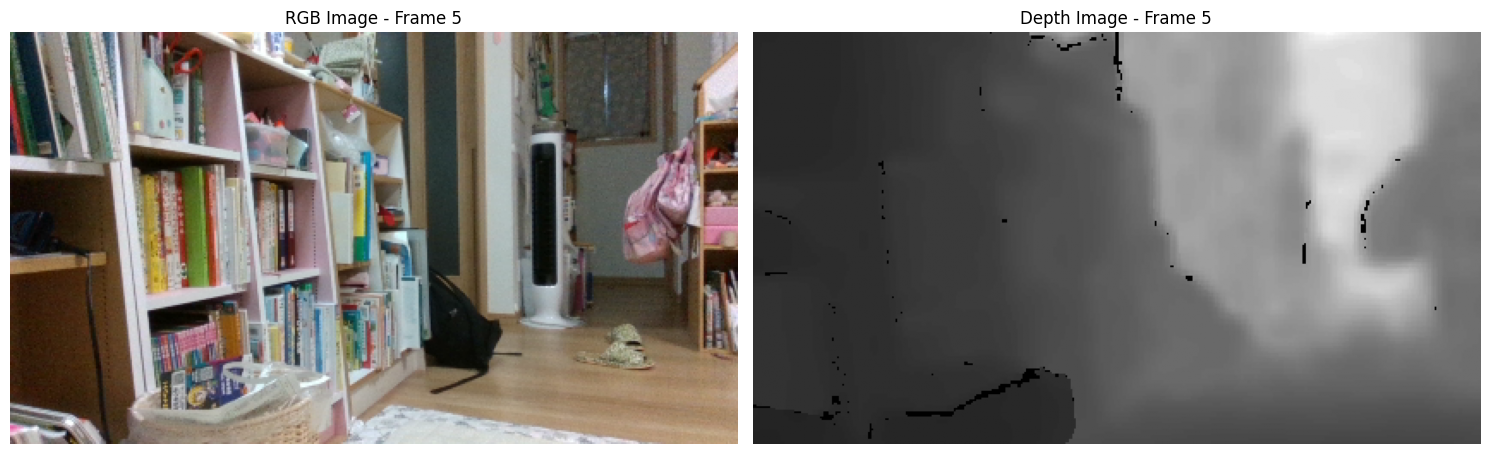

Frame 5: 中央のピクセル(212, 120)の距離: 1.515m


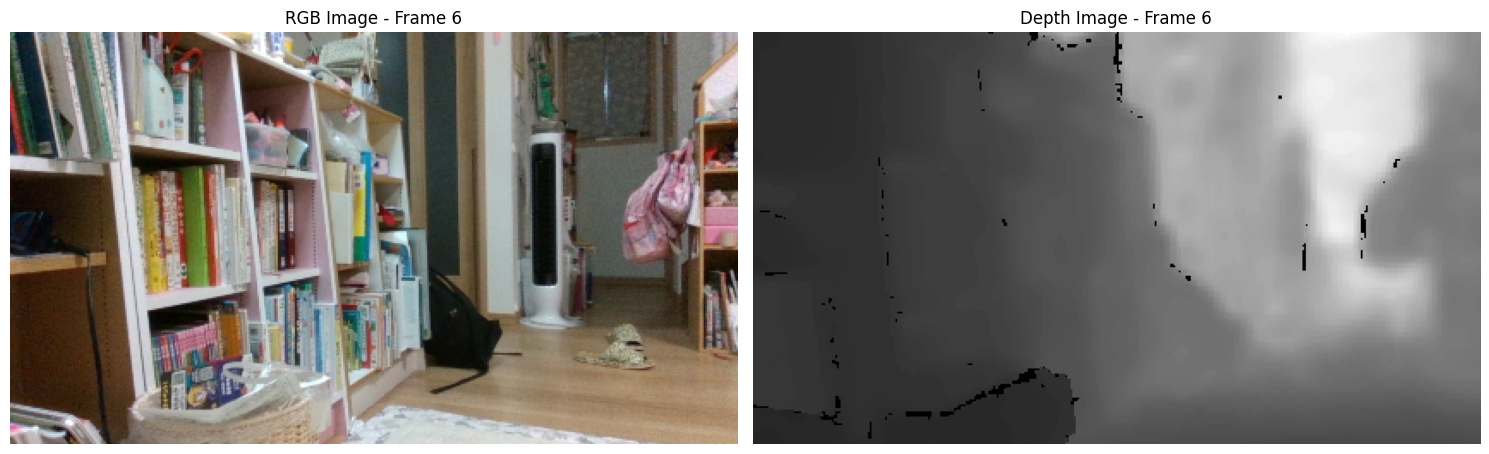

Frame 6: 中央のピクセル(212, 120)の距離: 1.515m


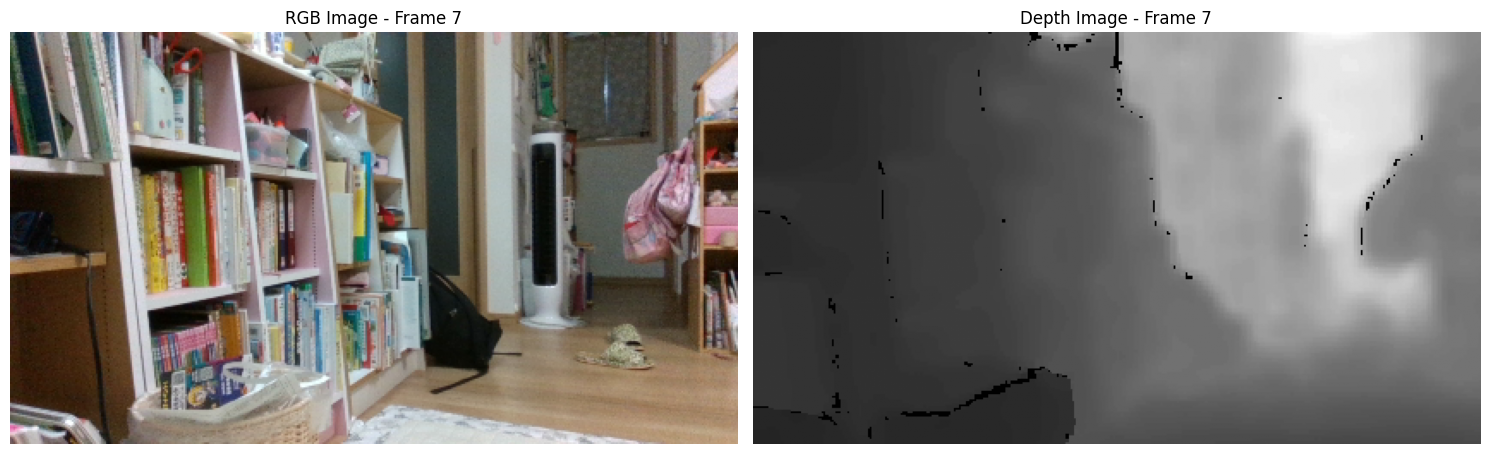

Frame 7: 中央のピクセル(212, 120)の距離: 1.515m


In [26]:
# RealSenseパイプラインの設定
pipeline = rs.pipeline()
config = rs.config()

# RGBとDepthストリームを有効にする
config.enable_stream(rs.stream.depth, 424, 240, rs.format.z16, 60)
config.enable_stream(rs.stream.color, 424, 240, rs.format.bgr8, 60)


# フレーム保存用のリスト
saved_frames = []
frame_times = []
distances = []

try:
    # ストリーミング開始
    pipeline.start(config)
    
    # アライメント設定（DepthをRGBに合わせる）
    align_to = rs.stream.color
    align = rs.align(align_to)
    
    print("RealSenseカメラから画像を取得中...")
    last_time = time.time()
    
    for i in range(7):  # 7フレーム取得
        # フレーム取得
        frames = pipeline.wait_for_frames()
        
        # フレームをアライメント
        aligned_frames = align.process(frames)
        
        # RGB画像とDepth画像を取得
        color_frame = aligned_frames.get_color_frame()
        depth_frame = aligned_frames.get_depth_frame()
        
        # 最初2フレームはスキップして安定させる
        if i < 2:
            color_frame.get_data()
            depth_frame.get_data()
            time.sleep(1)  # 1秒待機
            last_time = time.time()
            continue

        if not color_frame or not depth_frame:
            print(f"Frame {i+1}: フレーム取得失敗")
            continue
        
        # NumPy配列に変換
        color_image = np.asanyarray(color_frame.get_data())
        depth_image = np.asanyarray(depth_frame.get_data())

        # フレームレート計算用
        elapsed = time.time() - last_time
        fps = 1 / elapsed
        print(f"Frame {i+1}: 現在のFPS = {fps:.1f}")
        last_time = time.time()
                
        # 距離情報の例（中央のピクセル）
        height, width = depth_image.shape
        center_x, center_y = width // 2, height // 2
        distance = depth_frame.get_distance(center_x, center_y)
        
        # データを保存（描画は後で）
        saved_frames.append({
            'color_image': color_image.copy(),
            'depth_image': depth_image.copy(),
            'frame_number': i + 1
        })
        distances.append(distance)
        
    print("画像取得完了!")
        
except rs.error as e:
    print(f"RealSenseエラー: {e}")
except Exception as e:
    print(f"エラーが発生しました: {e}")
    print("RealSenseカメラが接続されているか確認してください")
    
finally:
    pipeline.stop()
    print("RealSenseパイプライン停止")

for i, frame_data in enumerate(saved_frames):
        color_image = frame_data['color_image']
        depth_image = frame_data['depth_image']
        frame_num = frame_data['frame_number']
        
        # BGR to RGB変換（matplotlib用）
        color_image_rgb = cv2.cvtColor(color_image, cv2.COLOR_BGR2RGB)
        
        # Depth画像を濃淡画像として正規化
        depth_gray = cv2.convertScaleAbs(depth_image, alpha=0.03)
        
        # 画像表示
        fig, axes = plt.subplots(1, 2, figsize=(15, 6))
        
        # RGB画像
        axes[0].imshow(color_image_rgb)
        axes[0].set_title(f'RGB Image - Frame {frame_num}')
        axes[0].axis('off')
        
        # Depth画像
        axes[1].imshow(depth_gray, cmap='gray')
        axes[1].set_title(f'Depth Image - Frame {frame_num}')
        axes[1].axis('off')
        
        plt.tight_layout()
        plt.show()
        
        # 距離情報の表示
        height, width = depth_image.shape
        center_x, center_y = width // 2, height // 2
        print(f"Frame {frame_num}: 中央のピクセル({center_x}, {center_y})の距離: {distances[i]:.3f}m")
        

## RGB画像の表示

RealSenseカメラから画像を取得中...


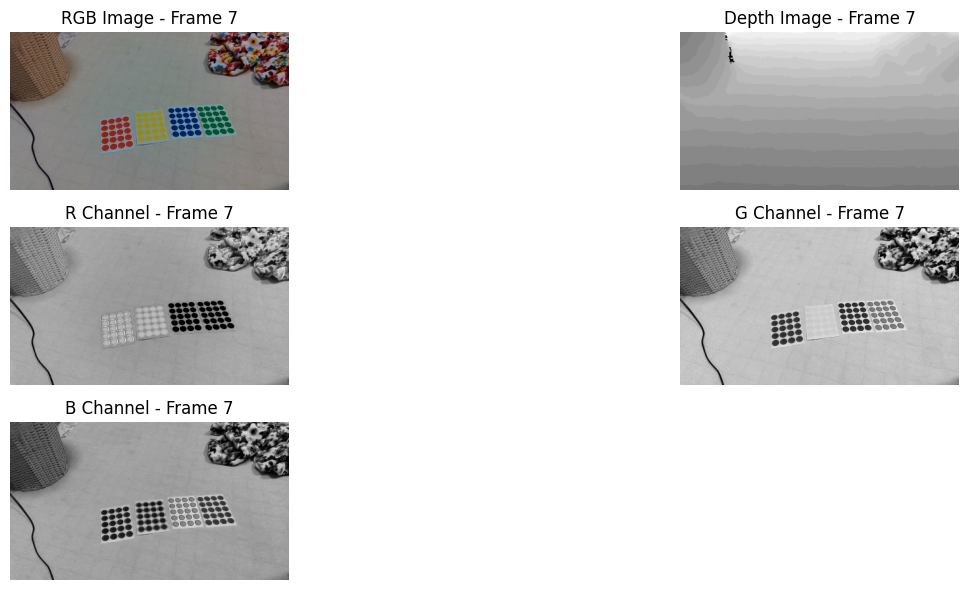

画像取得完了!
RealSenseパイプライン停止


In [35]:
# RealSenseパイプラインの設定
pipeline = rs.pipeline()
config = rs.config()

# RGBとDepthストリームを有効にする
config.enable_stream(rs.stream.depth, 424, 240, rs.format.z16, 60)
config.enable_stream(rs.stream.color, 424, 240, rs.format.bgr8, 60)

try:
    # ストリーミング開始
    pipeline.start(config)
    
    # アライメント設定（DepthをRGBに合わせる）
    align_to = rs.stream.color
    align = rs.align(align_to)
    
    print("RealSenseカメラから画像を取得中...")
    last_time = time.time()
    
    for i in range(3):  # 3フレーム取得
        # フレーム取得
        frames = pipeline.wait_for_frames()
        
        # フレームをアライメント
        aligned_frames = align.process(frames)
        
        # RGB画像とDepth画像を取得
        color_frame = aligned_frames.get_color_frame()
        depth_frame = aligned_frames.get_depth_frame()
        
        # 最初2フレームはスキップして安定させる
        if i < 2:
            color_frame.get_data()
            depth_frame.get_data()
            time.sleep(1)  # 1秒待機
            last_time = time.time()
            continue

        if not color_frame or not depth_frame:
            print(f"Frame {i+1}: フレーム取得失敗")
            continue
        
        # NumPy配列に変換
        color_image = np.asanyarray(color_frame.get_data())
        depth_image = np.asanyarray(depth_frame.get_data())

        # BGR to RGB変換（matplotlib用）
        color_image_rgb = cv2.cvtColor(color_image, cv2.COLOR_BGR2RGB)
        
        # Depth画像を濃淡画像として正規化
        depth_gray = cv2.convertScaleAbs(depth_image, alpha=0.03)
        
        # 画像表示
        fig, axes = plt.subplots(3, 2, figsize=(15, 6))
        
        # RGB画像
        axes[0, 0].imshow(color_image_rgb)
        axes[0, 0].set_title(f'RGB Image - Frame {frame_num}')
        axes[0, 0].axis('off')
        
        # Depth画像
        axes[0, 1].imshow(depth_gray, cmap='gray')
        axes[0, 1].set_title(f'Depth Image - Frame {frame_num}')
        axes[0, 1].axis('off')

        # Rチャンネル画像
        r_channel = color_image_rgb[:, :, 0]
        axes[1, 0].imshow(r_channel, cmap='gray')
        axes[1, 0].set_title(f'R Channel - Frame {frame_num}')
        axes[1, 0].axis('off')

        # Gチャンネル画像
        g_channel = color_image_rgb[:, :, 1]
        axes[1, 1].imshow(g_channel, cmap='gray')
        axes[1, 1].set_title(f'G Channel - Frame {frame_num}')
        axes[1, 1].axis('off')

        # Bチャンネル画像
        b_channel = color_image_rgb[:, :, 2]
        axes[2, 0].imshow(b_channel, cmap='gray')
        axes[2, 0].set_title(f'B Channel - Frame {frame_num}')
        axes[2, 0].axis('off')

        # 空の位置（右下）を非表示にする
        axes[2, 1].axis('off')
        axes[2, 1].set_visible(False)

        plt.tight_layout()
        plt.show()
        
    print("画像取得完了!")
        
except rs.error as e:
    print(f"RealSenseエラー: {e}")
except Exception as e:
    print(f"エラーが発生しました: {e}")
    print("RealSenseカメラが接続されているか確認してください")
    
finally:
    pipeline.stop()
    print("RealSenseパイプライン停止")


## 画像中の朱色の点を検索し、その中心の深度座標を出力する

In [63]:
# カラーコード#962012をBGRに変換
hex_color = "#962012"
# HTMLカラーコード(RGB)をBGRに変換
rgb_color = tuple(int(hex_color[i:i+2], 16) for i in (1, 3, 5))  # (150, 32, 18)
bgr_color = rgb_color[::-1]  # BGRに変換: (18, 32, 150)

print(f"RGB: {rgb_color}")
print(f"BGR: {bgr_color}")

# BGRをHSVに変換
bgr_array = np.uint8([[bgr_color]])
hsv_color = cv2.cvtColor(bgr_array, cv2.COLOR_BGR2HSV)[0][0]
print(f"HSV: {hsv_color}")

# HSV値から範囲を設定（色相の範囲を調整）
hue = hsv_color[0]
saturation = hsv_color[1] 
value = hsv_color[2]

# 色相の範囲を±10度、彩度と明度の範囲を±30で設定
lower_bound = np.array([max(0, hue-10), max(0, saturation-30), max(0, value-30)])
upper_bound = np.array([min(179, hue+10), min(255, saturation+30), min(255, value+30)])

print(f"Lower HSV: {lower_bound}")
print(f"Upper HSV: {upper_bound}")

RGB: (150, 32, 18)
BGR: (18, 32, 150)
HSV: [  3 224 150]
Lower HSV: [249 194 120]
Upper HSV: [ 13 254 180]


C:\Users\KentaYonekura\AppData\Local\Temp\ipykernel_14300\253716051.py:21: RuntimeWarning: overflow encountered in scalar subtract
  lower_bound = np.array([max(0, hue-10), max(0, saturation-30), max(0, value-30)])


RealSenseカメラから画像を取得中...
朱色の点の3D座標: x=0.052m, y=0.014m, z=0.535m
緑色の点の3D座標: x=0.039m, y=-0.119m, z=0.518m


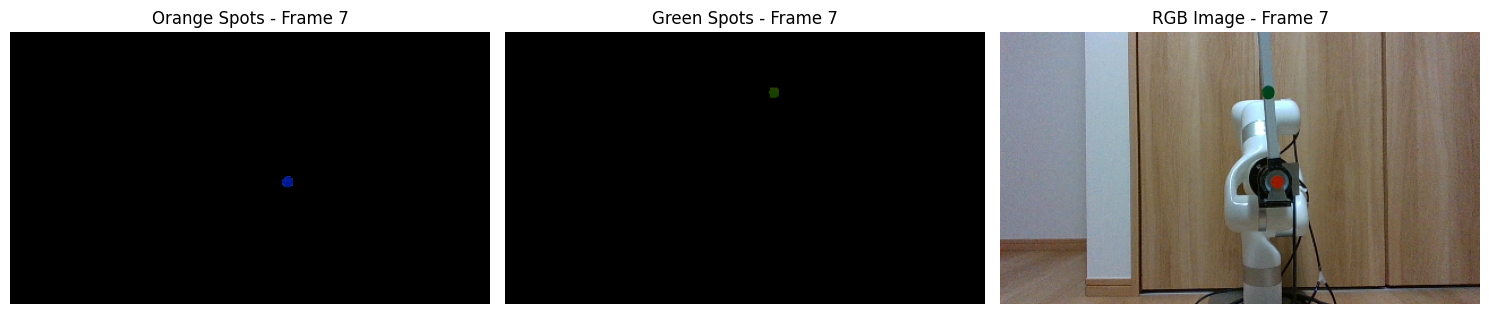

画像取得完了!
RealSenseパイプライン停止


In [75]:
# 画像中の朱色の点を検索し、その中心の深度座標を出力する
# このとき、点のサイズが閾値以下の場合は無視する

# RealSenseパイプラインの設定
pipeline = rs.pipeline()
config = rs.config()

# RGBとDepthストリームを有効にする
config.enable_stream(rs.stream.depth, 424, 240, rs.format.z16, 60)
config.enable_stream(rs.stream.color, 424, 240, rs.format.bgr8, 60)

# カメラの内部パラメータを取得
depth_intrin = depth_frame.profile.as_video_stream_profile().intrinsics

try:
    # ストリーミング開始
    pipeline.start(config)
    
    # アライメント設定（DepthをRGBに合わせる）
    align_to = rs.stream.color
    align = rs.align(align_to)
    
    print("RealSenseカメラから画像を取得中...")
    last_time = time.time()
    
    for i in range(3):  # 3フレーム取得
        # フレーム取得
        frames = pipeline.wait_for_frames()
        
        # フレームをアライメント
        aligned_frames = align.process(frames)
        
        # RGB画像とDepth画像を取得
        color_frame = aligned_frames.get_color_frame()
        depth_frame = aligned_frames.get_depth_frame()
        
        # 最初2フレームはスキップして安定させる
        if i < 2:
            color_frame.get_data()
            depth_frame.get_data()
            time.sleep(1)  # 1秒待機
            last_time = time.time()
            continue

        if not color_frame or not depth_frame:
            print(f"Frame {i+1}: フレーム取得失敗")
            continue
        
        # NumPy配列に変換
        color_image = np.asanyarray(color_frame.get_data())
        depth_image = np.asanyarray(depth_frame.get_data())

        # 朱色の点を検出
        hsv_image = cv2.cvtColor(color_image, cv2.COLOR_BGR2HSV)
        lower_orange = np.array([0, 190, 120])
        upper_orange = np.array([15, 255, 180])
        mask_orange = cv2.inRange(hsv_image, lower_orange, upper_orange)

        # 閾値以下のサイズのノイズを除去
        kernel = np.ones((3, 3), np.uint8)
        mask_orange = cv2.morphologyEx(mask_orange, cv2.MORPH_OPEN, kernel)
        mask_orange = cv2.morphologyEx(mask_orange, cv2.MORPH_CLOSE, kernel)
        contours_orange, _ = cv2.findContours(mask_orange, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

        # 緑色の点を検出
        hsv_image = cv2.cvtColor(color_image, cv2.COLOR_BGR2HSV)
        lower_green = np.array([65, 225, 50])
        upper_green = np.array([80, 255, 110])
        mask_green = cv2.inRange(hsv_image, lower_green, upper_green)

        # 閾値以下のサイズのノイズを除去
        kernel = np.ones((3, 3), np.uint8)
        mask_green = cv2.morphologyEx(mask_green, cv2.MORPH_OPEN, kernel)
        mask_green = cv2.morphologyEx(mask_green, cv2.MORPH_CLOSE, kernel)
        contours_green, _ = cv2.findContours(mask_green, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

        if contours_orange:
            # 最大の輪郭を取得
            largest_contour = max(contours_orange, key=cv2.contourArea)

            # 輪郭の中心を計算
            M = cv2.moments(largest_contour)
            if M["m00"] != 0:
                center_x = int(M["m10"] / M["m00"])
                center_y = int(M["m01"] / M["m00"])
                
                # 深度値を取得
                depth_value = depth_frame.get_distance(center_x, center_y)
                
                if depth_value > 0:
                    # 3D座標に変換
                    depth_intrin = depth_frame.profile.as_video_stream_profile().intrinsics
                    point_3d = rs.rs2_deproject_pixel_to_point(
                        depth_intrin, [center_x, center_y], depth_value
                    )
                    x, y, z = point_3d
                    
                    print(f"朱色の点の3D座標: x={x:.3f}m, y={y:.3f}m, z={z:.3f}m")
                else:
                    print("有効な深度値が取得できませんでした")

        if contours_green:
            # 最大の輪郭を取得
            largest_contour = max(contours_green, key=cv2.contourArea)

            # 輪郭の中心を計算
            M = cv2.moments(largest_contour)
            if M["m00"] != 0:
                center_x = int(M["m10"] / M["m00"])
                center_y = int(M["m01"] / M["m00"])
                
                # 深度値を取得
                depth_value = depth_frame.get_distance(center_x, center_y)
                
                if depth_value > 0:
                    # 3D座標に変換
                    depth_intrin = depth_frame.profile.as_video_stream_profile().intrinsics
                    point_3d = rs.rs2_deproject_pixel_to_point(
                        depth_intrin, [center_x, center_y], depth_value
                    )
                    x, y, z = point_3d
                    
                    print(f"緑色の点の3D座標: x={x:.3f}m, y={y:.3f}m, z={z:.3f}m")
                else:
                    print("有効な深度値が取得できませんでした")

        # マスクを使って元の画像から点を抽出
        orange_spots = cv2.bitwise_and(color_image, color_image, mask=mask_orange)
        green_spots = cv2.bitwise_and(color_image, color_image, mask=mask_green)

        # Depth画像を濃淡画像として正規化
        depth_gray = cv2.convertScaleAbs(depth_image, alpha=0.03)
        
        # BGR to RGB変換（matplotlib用）
        color_image_rgb = cv2.cvtColor(color_image, cv2.COLOR_BGR2RGB)

        # 画像表示
        fig, axes = plt.subplots(1, 3, figsize=(15, 6))
        
        # 朱色領域の画像
        axes[0].imshow(orange_spots)
        axes[0].set_title(f'Orange Spots - Frame {frame_num}')
        axes[0].axis('off')

        # 緑色領域の画像
        axes[1].imshow(green_spots)
        axes[1].set_title(f'Green Spots - Frame {frame_num}')
        axes[1].axis('off')

        # RGB画像
        axes[2].imshow(color_image_rgb)
        axes[2].set_title(f'RGB Image - Frame {frame_num}')
        axes[2].axis('off')

        plt.tight_layout()
        plt.show()
        
    print("画像取得完了!")
        
except rs.error as e:
    print(f"RealSenseエラー: {e}")
except Exception as e:
    print(f"エラーが発生しました: {e}")
    print("RealSenseカメラが接続されているか確認してください")
    
finally:
    pipeline.stop()
    print("RealSenseパイプライン停止")

In [77]:
# RealSenseを使って取得した朱色の点と緑色の点の3D座標を使って角度を計算する
# 朱色の点を中心として、真上を0度、反時計回りを正として角度を計算する

# RealSenseパイプラインの設定
pipeline = rs.pipeline()
config = rs.config()

# RGBとDepthストリームを有効にする
config.enable_stream(rs.stream.depth, 424, 240, rs.format.z16, 60)
config.enable_stream(rs.stream.color, 424, 240, rs.format.bgr8, 60)

# カメラの内部パラメータを取得
depth_intrin = depth_frame.profile.as_video_stream_profile().intrinsics

# 朱色の点と緑色の点の3D座標を保存する変数
orange_point_3d = None
green_point_3d = None

last_time = time.time()

try:
    # ストリーミング開始
    pipeline.start(config)
    
    # アライメント設定（DepthをRGBに合わせる）
    align_to = rs.stream.color
    align = rs.align(align_to)
    
    print("RealSenseカメラから画像を取得中...")
    last_time = time.time()
    
    for i in range(3):  # 3フレーム取得
        # フレーム取得
        frames = pipeline.wait_for_frames()
        
        # フレームをアライメント
        aligned_frames = align.process(frames)
        
        # RGB画像とDepth画像を取得
        color_frame = aligned_frames.get_color_frame()
        depth_frame = aligned_frames.get_depth_frame()
        
        # 最初2フレームはスキップして安定させる
        if i < 2:
            color_frame.get_data()
            depth_frame.get_data()
            time.sleep(1)  # 1秒待機
            last_time = time.time()
            continue

        if not color_frame or not depth_frame:
            print(f"Frame {i+1}: フレーム取得失敗")
            continue
        
        # NumPy配列に変換
        color_image = np.asanyarray(color_frame.get_data())
        depth_image = np.asanyarray(depth_frame.get_data())

        # 朱色の点を検出
        hsv_image = cv2.cvtColor(color_image, cv2.COLOR_BGR2HSV)
        lower_orange = np.array([0, 190, 120])
        upper_orange = np.array([15, 255, 180])
        mask_orange = cv2.inRange(hsv_image, lower_orange, upper_orange)

        # 閾値以下のサイズのノイズを除去
        kernel = np.ones((3, 3), np.uint8)
        mask_orange = cv2.morphologyEx(mask_orange, cv2.MORPH_OPEN, kernel)
        mask_orange = cv2.morphologyEx(mask_orange, cv2.MORPH_CLOSE, kernel)
        contours_orange, _ = cv2.findContours(mask_orange, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

        # 緑色の点を検出
        hsv_image = cv2.cvtColor(color_image, cv2.COLOR_BGR2HSV)
        lower_green = np.array([65, 225, 50])
        upper_green = np.array([80, 255, 110])
        mask_green = cv2.inRange(hsv_image, lower_green, upper_green)

        # 閾値以下のサイズのノイズを除去
        kernel = np.ones((3, 3), np.uint8)
        mask_green = cv2.morphologyEx(mask_green, cv2.MORPH_OPEN, kernel)
        mask_green = cv2.morphologyEx(mask_green, cv2.MORPH_CLOSE, kernel)
        contours_green, _ = cv2.findContours(mask_green, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

        if contours_orange:
            # 最大の輪郭を取得
            largest_contour = max(contours_orange, key=cv2.contourArea)

            # 輪郭の中心を計算
            M = cv2.moments(largest_contour)
            if M["m00"] != 0:
                center_x = int(M["m10"] / M["m00"])
                center_y = int(M["m01"] / M["m00"])
                
                # 深度値を取得
                depth_value = depth_frame.get_distance(center_x, center_y)
                
                if depth_value > 0:
                    # 3D座標に変換
                    depth_intrin = depth_frame.profile.as_video_stream_profile().intrinsics
                    point_3d = rs.rs2_deproject_pixel_to_point(
                        depth_intrin, [center_x, center_y], depth_value
                    )
                    orange_point_3d = point_3d

                    print(f"朱色の点の3D座標: x={orange_point_3d[0]:.3f}m, y={orange_point_3d[1]:.3f}m, z={orange_point_3d[2]:.3f}m")
                else:
                    print("有効な深度値が取得できませんでした")

        if contours_green:
            # 最大の輪郭を取得
            largest_contour = max(contours_green, key=cv2.contourArea)

            # 輪郭の中心を計算
            M = cv2.moments(largest_contour)
            if M["m00"] != 0:
                center_x = int(M["m10"] / M["m00"])
                center_y = int(M["m01"] / M["m00"])
                
                # 深度値を取得
                depth_value = depth_frame.get_distance(center_x, center_y)
                
                if depth_value > 0:
                    # 3D座標に変換
                    depth_intrin = depth_frame.profile.as_video_stream_profile().intrinsics
                    point_3d = rs.rs2_deproject_pixel_to_point(
                        depth_intrin, [center_x, center_y], depth_value
                    )
                    green_point_3d = point_3d

                    print(f"緑色の点の3D座標: x={green_point_3d[0]:.3f}m, y={green_point_3d[1]:.3f}m, z={green_point_3d[2]:.3f}m")
                else:
                    print("有効な深度値が取得できませんでした")
        
        if contours_orange and contours_green and orange_point_3d is not None and green_point_3d is not None:
            # 朱色の点と緑色の点の2D座標を取得
            orange_2d = np.array([-orange_point_3d[1], -orange_point_3d[0]])
            green_2d = np.array([-green_point_3d[1], -green_point_3d[0]])
            
            # 2Dベクトルを計算
            vector = green_2d - orange_2d
            
            # 角度を計算（atan2を使用して反時計回りを正とする）
            angle_rad = np.arctan2(vector[1], vector[0])
            angle_deg = np.degrees(angle_rad)
            
            print(f"朱色の点の座標: x={-orange_point_3d[1]:.3f}m, y={-orange_point_3d[0]:.3f}m")
            print(f"朱色の点を中心とした緑色の点の角度: {angle_deg:.2f}度")
            print(f"フレームレート: {1/(time.time() - last_time):.1f} FPS")
        
        last_time = time.time()
            
except rs.error as e:
    print(f"RealSenseエラー: {e}")
except Exception as e:
    print(f"エラーが発生しました: {e}")
    print("RealSenseカメラが接続されているか確認してください")
    
finally:
    pipeline.stop()
    print("RealSenseパイプライン停止")

RealSenseカメラから画像を取得中...
朱色の点の3D座標: x=0.052m, y=0.016m, z=0.534m
緑色の点の3D座標: x=-0.079m, y=0.047m, z=0.534m
朱色の点の座標: x=-0.016m, y=-0.052m
朱色の点を中心とした緑色の点の角度: 103.32度
フレームレート: 100.6 FPS
RealSenseパイプライン停止
